<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day09-backprop-training-regularization.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 9 — Backpropagation, Training, and Regularization, in code {.unnumbered}

This notebook rebuilds Day 8's exact subcellular-localization dataset
and network (self-contained, so this notebook runs on its own), then
does what Day 8 deliberately stopped short of: implements the standard
PyTorch training loop, demonstrates *why* deep networks with saturating
activations are hard to train (the vanishing-gradient problem), applies
dropout/L2/early-stopping to fight overfitting, and reports the trained
model's real accuracy — directly comparable to Day 8's untrained
baseline.

In [1]:
import re, os, shutil, subprocess, tempfile
import numpy as np
import requests
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, matthews_corrcoef,
)

torch.manual_seed(0)
np.random.seed(0)

## Rebuilding Day 8's dataset and model

Identical to Day 8's notebook: fetch the same five UniProt subcellular-
location classes, keep only unambiguous single-location entries, balance
the classes, one-hot encode (150 residues x 20 amino acids, flattened),
and use Day 8's **homology-aware split** (MMseqs2 clusters at 30%
identity, whole clusters assigned to train, validation or test).

In [2]:
UNIPROT_CLASSES = {
    "Cytoplasm": "SL-0086",
    "Nucleus": "SL-0191",
    "Mitochondrion": "SL-0173",
    "Secreted": "SL-0243",
    "Cell membrane": "SL-0039",
}
CLASS_NAMES = list(UNIPROT_CLASSES.keys())

def fetch_uniprot(sl_code, size=500):
    query = f"organism_id:9606 AND reviewed:true AND cc_scl_term:{sl_code} AND length:[50 TO 500]"
    r = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params={"query": query, "fields": "accession,sequence,cc_subcellular_location",
                "format": "tsv", "size": size},
        timeout=60,
    )
    r.raise_for_status()
    rows = []
    for line in r.text.strip().split("\n")[1:]:
        parts = line.split("\t")
        if len(parts) == 3:
            rows.append(tuple(parts))  # (accession, sequence, location_text)
    return rows

def is_unambiguous_single_location(location_text, target):
    '''Keep only entries whose SUBCELLULAR LOCATION comment names exactly
    one location term (matching the target), ignoring free-text Notes,
    evidence-code tags, and skipping isoform-specific annotations.'''
    location_text = re.sub(r"Note=.*", "", location_text)
    location_text = re.sub(r"\{[^}]*\}", "", location_text)
    if "Isoform" in location_text:
        return False
    terms = set()
    for statement in [s.strip() for s in location_text.split(".") if s.strip()]:
        body = statement.split(":", 1)[-1] if ":" in statement else statement
        top_term = re.split(r"[,;]", body)[0].strip()
        if top_term:
            terms.add(top_term)
    return len(terms) == 1 and next(iter(terms)) == target

entries_by_class = {}
for class_name, sl_code in UNIPROT_CLASSES.items():
    raw = fetch_uniprot(sl_code)
    clean = [(acc, seq) for acc, seq, loc in raw if is_unambiguous_single_location(loc, class_name)]
    entries_by_class[class_name] = clean
    print(f"{class_name:15s} raw hits: {len(raw):4d}   unambiguous single-location: {len(clean):4d}")

N_PER_CLASS = min(len(v) for v in entries_by_class.values())
rng = np.random.RandomState(0)
balanced_accs, balanced_seqs, balanced_labels = [], [], []
for class_idx, class_name in enumerate(CLASS_NAMES):
    pool = entries_by_class[class_name]
    for i in rng.choice(len(pool), N_PER_CLASS, replace=False):
        balanced_accs.append(pool[i][0])
        balanced_seqs.append(pool[i][1])
        balanced_labels.append(class_idx)

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
SEQ_LEN = 150

def one_hot_encode(sequence, length=SEQ_LEN):
    encoded = np.zeros((length, len(AMINO_ACIDS)), dtype=np.float32)
    for position, residue in enumerate(sequence[:length]):
        if residue in AA_TO_INDEX:
            encoded[position, AA_TO_INDEX[residue]] = 1.0
    return encoded.flatten()

X = np.stack([one_hot_encode(s) for s in balanced_seqs])
y = np.array(balanced_labels)

# Day 8's homology-aware split: MMseqs2 clusters at 30% identity, whole clusters per split
CLUSTER_URL = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/day08-subcell-mmseqs-30.tsv"
LOCAL_TSV = "data/day08-subcell-mmseqs-30.tsv"

def mmseqs_clusters(accs, seqs, min_seq_id=0.3):
    tmp = tempfile.mkdtemp()
    with open(f"{tmp}/in.fasta", "w") as f:
        for a, s in zip(accs, seqs):
            f.write(f">{a}\n{s}\n")
    subprocess.run(["mmseqs", "easy-cluster", f"{tmp}/in.fasta", f"{tmp}/clu", f"{tmp}/work",
                    "--min-seq-id", str(min_seq_id), "-c", "0.5", "-v", "1"],
                   check=True, stdout=subprocess.DEVNULL)
    pairs = [line.split("\t") for line in open(f"{tmp}/clu_cluster.tsv").read().split("\n") if line]
    shutil.rmtree(tmp)
    return {member: rep for rep, member in pairs}

def load_precomputed_clusters():
    text = open(LOCAL_TSV).read() if os.path.exists(LOCAL_TSV) else requests.get(CLUSTER_URL, timeout=30).text
    pairs = [line.split("\t") for line in text.strip().split("\n")[1:]]
    return {member: rep for rep, member in pairs}

if shutil.which("mmseqs"):
    member_to_rep = mmseqs_clusters(balanced_accs, balanced_seqs)
    print("clustered with local MMseqs2 (30% identity, 50% coverage)")
else:
    member_to_rep = load_precomputed_clusters()
    print("mmseqs not found -- loaded the precomputed MMseqs2 clustering")

# proteins missing from the clustering (e.g. if UniProt changed) become their own cluster
reps = [member_to_rep.get(a, a) for a in balanced_accs]
rep_ids = {r: i for i, r in enumerate(sorted(set(reps)))}
groups = np.array([rep_ids[r] for r in reps])
sizes = np.bincount(groups)
print(f"{len(y)} proteins -> {len(sizes)} clusters; "
      f"{(sizes > 1).sum()} clusters have more than one member ({sizes[sizes > 1].sum()} proteins), largest has {sizes.max()}")

def homology_split(y, groups, fractions=(0.70, 0.15, 0.15), seed=0):
    '''Assign whole clusters, in random order, to train/val/test: each cluster
    goes to the split furthest below its target share of that cluster's
    classes (ties broken at random). Returns three index arrays.'''
    rng = np.random.RandomState(seed)
    n_classes = y.max() + 1
    target = np.outer(fractions, np.bincount(y, minlength=n_classes))   # (3 splits, n_classes)
    have = np.zeros_like(target)
    assignment = {}
    for g in rng.permutation(np.unique(groups)):
        cls_counts = np.bincount(y[groups == g], minlength=n_classes)
        deficit = ((target - have) * (cls_counts > 0)).sum(axis=1) / target.sum(axis=1)
        best = np.flatnonzero(deficit == deficit.max())
        split = int(rng.choice(best))
        assignment[g] = split
        have[split] += cls_counts
    split_of = np.array([assignment[g] for g in groups])
    return [np.where(split_of == k)[0] for k in range(3)]

tr_h, va_h, te_h = homology_split(y, groups)
X_train, y_train = X[tr_h], y[tr_h]
X_val, y_val = X[va_h], y[va_h]
X_test, y_test = X[te_h], y[te_h]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

print(f"dataset rebuilt: {len(balanced_seqs)} sequences, {N_PER_CLASS} per class")
print(f"homology-aware split -- train: {len(X_train)}   val: {len(X_val)}   test: {len(X_test)}")


class SubcellularLocalizationClassifier(nn.Module):
    def __init__(self, input_dim=SEQ_LEN * len(AMINO_ACIDS), hidden_dim=64, n_classes=5, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.net(x)

print("model class ready:", SubcellularLocalizationClassifier().net)

Cytoplasm       raw hits:  500   unambiguous single-location:  424


Nucleus         raw hits:  500   unambiguous single-location:  497


Mitochondrion   raw hits:  500   unambiguous single-location:  140


Secreted        raw hits:  500   unambiguous single-location:  488


Cell membrane   raw hits:  500   unambiguous single-location:  338


clustered with local MMseqs2 (30% identity, 50% coverage)
700 proteins -> 551 clusters; 75 clusters have more than one member (224 proteins), largest has 11
dataset rebuilt: 700 sequences, 140 per class
homology-aware split -- train: 486   val: 105   test: 109
model class ready: Sequential(
  (0): Linear(in_features=3000, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.0, inplace=False)
  (3): Linear(in_features=64, out_features=5, bias=True)
)


## Backpropagation: the chain rule, layer by layer

Day 1 introduced the chain rule; a network with a hidden layer is
exactly a composition of functions, $\hat y = f_2(f_1(x))$, so training
it needs the loss's derivative with respect to *every* weight in *both*
layers. Backpropagation is not a different algorithm from the chain rule
— it is the chain rule, applied systematically from the output layer
backward to the input layer, reusing each layer's already-computed
derivative rather than recomputing it from scratch. PyTorch's
`loss.backward()` does exactly this automatically for a graph of any
depth; that automation is *why* a framework rather than hand-written
gradient descent (as in Day 6's from-scratch notebook) becomes essential
once a model has more than one layer.

### Further reading

- Wikipedia, [Backpropagation](https://en.wikipedia.org/wiki/Backpropagation)

### A tiny worked example, by hand, verified against autograd

The real classifier above has 192,389 weights — far too many to trace
by hand. But the *mechanics* are identical however many weights there
are, so here's a miniature stand-in with the same structure (one hidden
layer, then an output layer) shrunk to 2 inputs, 1 hidden unit (tanh),
and 1 output unit (sigmoid), small enough to compute completely by
hand — and then checked against what PyTorch's own `autograd` computes
for the exact same numbers, so this isn't just illustrative, it's a real
verification that the by-hand chain-rule derivation is correct.

**Forward pass:** with hidden pre-activation $z_g = w_{xg0} + w_{xg1}
x_1 + w_{xg2} x_2$, hidden output $y_g = \tanh(z_g)$, output
pre-activation $z_f = w_{gf0} + w_{gf1} y_g$, prediction $y_f =
\sigma(z_f)$, and squared-error loss $E = \tfrac{1}{2}(y_{\text{truth}}
- y_f)^2$:

In [3]:
def forward_two_layer(x1, x2, wxg0, wxg1, wxg2, wgf0, wgf1):
    zg = wxg0 + wxg1 * x1 + wxg2 * x2
    yg = np.tanh(zg)
    zf = wgf0 + wgf1 * yg
    yf = 1.0 / (1.0 + np.exp(-zf))
    return zg, yg, zf, yf

# A small, arbitrary set of weights and one training example
wxg0, wxg1, wxg2 = 0.3, 0.6, -0.1
wgf0, wgf1 = -0.2, 0.5
x1, x2 = -0.9, 0.1
y_truth = 1.0

zg, yg, zf, yf = forward_two_layer(x1, x2, wxg0, wxg1, wxg2, wgf0, wgf1)
loss = 0.5 * (y_truth - yf) ** 2

print(f"zg = {zg:+.6f}   yg = tanh(zg) = {yg:+.6f}")
print(f"zf = {zf:+.6f}   yf = sigmoid(zf) = {yf:+.6f}")
print(f"loss = 0.5*(y_truth - yf)^2 = {loss:.6f}")

zg = -0.250000   yg = tanh(zg) = -0.244919
zf = -0.322459   yf = sigmoid(zf) = +0.420077
loss = 0.5*(y_truth - yf)^2 = 0.168156


**Backward pass, by the chain rule, one layer at a time** — starting
from the loss and working back to the inputs, exactly as
backpropagation does for a network of any depth:

$$
\frac{\partial E}{\partial y_f} = -(y_{\text{truth}} - y_f) \qquad
\frac{\partial y_f}{\partial z_f} = y_f(1-y_f) \qquad
\frac{\partial E}{\partial z_f} = \frac{\partial E}{\partial y_f}\cdot\frac{\partial y_f}{\partial z_f}
$$

That last quantity — the error signal *at* the output unit — is exactly
what gets reused (not recomputed) to get every gradient in the layer
before it:

$$
\frac{\partial E}{\partial w_{gf1}} = \frac{\partial E}{\partial z_f}\cdot y_g \qquad
\frac{\partial E}{\partial y_g} = \frac{\partial E}{\partial z_f}\cdot w_{gf1} \qquad
\frac{\partial y_g}{\partial z_g} = 1-y_g^2 \qquad
\frac{\partial E}{\partial z_g} = \frac{\partial E}{\partial y_g}\cdot\frac{\partial y_g}{\partial z_g}
$$

$$
\frac{\partial E}{\partial w_{xg1}} = \frac{\partial E}{\partial z_g}\cdot x_1 \qquad
\frac{\partial E}{\partial w_{xg2}} = \frac{\partial E}{\partial z_g}\cdot x_2
$$

In [4]:
def backward_two_layer(x1, x2, y_truth, yg, zf, yf, wgf1):
    dE_dyf = -(y_truth - yf)
    dyf_dzf = yf * (1.0 - yf)
    dE_dzf = dE_dyf * dyf_dzf                # error signal at the output unit

    dE_dwgf0 = dE_dzf * 1.0
    dE_dwgf1 = dE_dzf * yg

    dE_dyg = dE_dzf * wgf1
    dyg_dzg = 1.0 - yg ** 2
    dE_dzg = dE_dyg * dyg_dzg                # error signal at the hidden unit

    dE_dwxg0 = dE_dzg * 1.0
    dE_dwxg1 = dE_dzg * x1
    dE_dwxg2 = dE_dzg * x2

    return dict(wxg0=dE_dwxg0, wxg1=dE_dwxg1, wxg2=dE_dwxg2, wgf0=dE_dwgf0, wgf1=dE_dwgf1)

hand_grads = backward_two_layer(x1, x2, y_truth, yg, zf, yf, wgf1)
print("Gradients computed by hand, via the chain rule:")
for name, g in hand_grads.items():
    print(f"  dE/d{name} = {g:+.6f}")

Gradients computed by hand, via the chain rule:
  dE/dwxg0 = -0.066401
  dE/dwxg1 = +0.059761
  dE/dwxg2 = -0.006640
  dE/dwgf0 = -0.141276
  dE/dwgf1 = +0.034601


**Checking this against PyTorch's own `autograd`** — build the
identical tiny network as real tensors with `requires_grad=True`, run
the identical forward pass, call `loss.backward()`, and compare:

In [5]:
wxg0_t = torch.tensor(wxg0, requires_grad=True)
wxg1_t = torch.tensor(wxg1, requires_grad=True)
wxg2_t = torch.tensor(wxg2, requires_grad=True)
wgf0_t = torch.tensor(wgf0, requires_grad=True)
wgf1_t = torch.tensor(wgf1, requires_grad=True)

zg_t = wxg0_t + wxg1_t * x1 + wxg2_t * x2
yg_t = torch.tanh(zg_t)
zf_t = wgf0_t + wgf1_t * yg_t
yf_t = torch.sigmoid(zf_t)
loss_t = 0.5 * (y_truth - yf_t) ** 2

loss_t.backward()

autograd_grads = dict(wxg0=wxg0_t.grad.item(), wxg1=wxg1_t.grad.item(), wxg2=wxg2_t.grad.item(),
                       wgf0=wgf0_t.grad.item(), wgf1=wgf1_t.grad.item())

print(f"{'weight':8}{'by hand':>14}{'autograd':>14}{'match?':>10}")
for name in hand_grads:
    h, a = hand_grads[name], autograd_grads[name]
    print(f"{name:8}{h:>+14.8f}{a:>+14.8f}{'yes' if np.isclose(h, a) else 'NO':>10}")

assert all(np.isclose(hand_grads[n], autograd_grads[n]) for n in hand_grads), "hand-derived gradients do not match autograd!"
print("\nEvery hand-derived gradient matches autograd exactly.")

weight         by hand      autograd    match?
wxg0       -0.06640098   -0.06640099       yes
wxg1       +0.05976089   +0.05976089       yes
wxg2       -0.00664010   -0.00664010       yes
wgf0       -0.14127646   -0.14127646       yes
wgf1       +0.03460124   +0.03460124       yes

Every hand-derived gradient matches autograd exactly.


Every gradient matches. This is the whole of backpropagation: the chain
rule, applied systematically, reusing each layer's error signal
($\partial E/\partial z_f$, then $\partial E/\partial z_g$) rather than
recomputing derivatives from scratch for every individual weight. The
real classifier's `loss.backward()` below runs exactly this algorithm —
just with 192,389 weights and several matrix layers instead of five
scalars, which is precisely why it needs automation rather than a
hand-written `backward_two_layer` function.

### Further watching

- 3Blue1Brown, [What is backpropagation really doing?](https://www.youtube.com/watch?v=Ilg3gGewQ5U) — the same idea as above, built up visually
- 3Blue1Brown, [Backpropagation calculus](https://www.youtube.com/watch?v=tIeHLnjs5U8) — the chain-rule mechanics in full, for a general multi-layer network

## The standard PyTorch training loop

Four steps, repeated: **forward pass** (compute predictions), **compute
loss**, **`loss.backward()`** (backpropagation — fills in every weight's
gradient), **`optimizer.step()`** (updates every weight using its
gradient). First, without any regularization, to see what happens:

In [6]:
torch.manual_seed(0)
model_plain = SubcellularLocalizationClassifier(dropout=0.0)
optimizer = torch.optim.Adam(model_plain.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

history = []
for epoch in range(30):
    model_plain.train()
    optimizer.zero_grad()
    logits = model_plain(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    model_plain.eval()
    with torch.no_grad():
        train_acc = (model_plain(X_train_t).argmax(1).numpy() == y_train).mean()
        val_acc = (model_plain(X_val_t).argmax(1).numpy() == y_val).mean()
    history.append((epoch, loss.item(), train_acc, val_acc))
    if epoch % 5 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}: loss {loss.item():.3f}   train acc {train_acc:.3f}   val acc {val_acc:.3f}")

epoch  0: loss 1.611   train acc 0.541   val acc 0.210
epoch  5: loss 1.261   train acc 0.990   val acc 0.486
epoch 10: loss 0.878   train acc 0.994   val acc 0.476
epoch 15: loss 0.549   train acc 0.996   val acc 0.476
epoch 20: loss 0.317   train acc 1.000   val acc 0.457
epoch 25: loss 0.175   train acc 1.000   val acc 0.448
epoch 29: loss 0.109   train acc 1.000   val acc 0.438


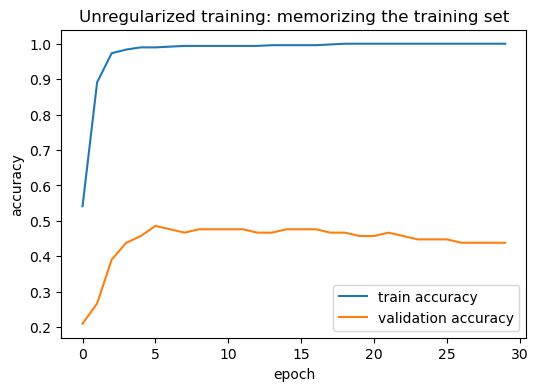

final train accuracy: 1.000   final val accuracy: 0.438
peak val accuracy: 0.486 at epoch 5


In [7]:
import matplotlib.pyplot as plt
epochs, losses, train_accs, val_accs = zip(*history)
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_accs, label="train accuracy")
plt.plot(epochs, val_accs, label="validation accuracy")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.title("Unregularized training: memorizing the training set")
plt.show()
print(f"final train accuracy: {train_accs[-1]:.3f}   final val accuracy: {val_accs[-1]:.3f}")
peak = int(np.argmax(val_accs))
print(f"peak val accuracy: {val_accs[peak]:.3f} at epoch {peak}")

Training accuracy reaches essentially 100% while validation accuracy
plateaus far below it — classic **overfitting**. This dataset makes it
almost inevitable: 486 training examples against a 3000-dimensional
input and ~190,000 parameters gives the network far more freedom than
data, so it memorizes idiosyncrasies of the specific training sequences
rather than learning the general signal. This is exactly the problem the
regularization techniques below exist to fight.

### Further reading

- Wikipedia, [Overfitting](https://en.wikipedia.org/wiki/Overfitting)

## Cross-entropy: why this is the loss

`loss_fn = nn.CrossEntropyLoss()` above was used without explaining why. For a softmax classifier it's the natural choice, not an arbitrary pick: softmax's output is a full probability distribution over the 5 localization classes, and cross-entropy measures how far that predicted distribution is from the true one (all probability on the one correct class). For a single example it reduces to

$$
\text{CE} = -\log p(\text{true class})
$$

— the negative log of the probability the model assigned to the correct answer. Confidently wrong is punished far more than hedged: predicting the true class with probability 0.9 costs $-\log(0.9) \approx 0.105$; predicting it with probability 0.01 costs $-\log(0.01) \approx 4.6$ — over 40x worse, for what might be the same single misclassified example.

In [8]:
model_plain.eval()
y_val_t = torch.tensor(y_val, dtype=torch.long)
with torch.no_grad():
    logits_val = model_plain(X_val_t)
    probs_val = torch.softmax(logits_val, dim=1)
    true_class_probs = probs_val[torch.arange(len(y_val_t)), y_val_t]
    by_hand_ce = -torch.log(true_class_probs).mean().item()
    pytorch_ce = loss_fn(logits_val, y_val_t).item()

print(f"Cross-entropy computed by hand:  {by_hand_ce:.6f}")
print(f"nn.CrossEntropyLoss() value:     {pytorch_ce:.6f}")
print(f"Match to 6 decimal places: {abs(by_hand_ce - pytorch_ce) < 1e-6}")

Cross-entropy computed by hand:  1.305748
nn.CrossEntropyLoss() value:     1.305748
Match to 6 decimal places: True


Matches exactly -- `nn.CrossEntropyLoss()` is computing exactly this quantity, not something more mysterious.

This is the same quantity Day 4 introduced from the other direction. Day 4's "Statistical significance of an alignment score" section used **relative entropy** (KL-divergence) to measure how surprising a real alignment's substitutions are compared to a random background -- and cross-entropy is built from exactly that: $H(P, Q) = H(P) + D_{\text{KL}}(P \| Q)$, the true distribution's own entropy plus the extra cost of using the model's imperfect distribution $Q$ instead of the true one $P$. Minimizing cross-entropy during training *is*, precisely, minimizing that same KL-divergence between the model's predictions and the true labels -- the same log-odds machinery Day 4 used to score alignments is what drives every softmax classifier's training here.

### Further watching

- 3Blue1Brown, [But what is cross-entropy? | Compression is Intelligence Part 2](https://www.youtube.com/watch?v=GlYgs6v2YfU) -- cross-entropy from the information-theory side, building up from first principles

## Vanishing gradients: why activation choice matters for depth

Sigmoid and tanh saturate (flatten) for large $|x|$ (Day 8), so their
derivative there is near zero. In a deep network, the chain rule
*multiplies* these derivatives together across layers — a handful of
small numbers multiplied together compounds fast. A concrete check: a
6-hidden-layer network, once with sigmoid activations and once with
ReLU, both freshly initialized, one backward pass each, comparing the
average gradient magnitude reaching each layer's weights (layer 1 =
closest to the input, most affected by the chain of multiplications):

### First: how much gradient does each activation pass on?

The chain rule multiplies one activation *derivative* per layer, so start
with the derivatives of Day 8's three activation functions:

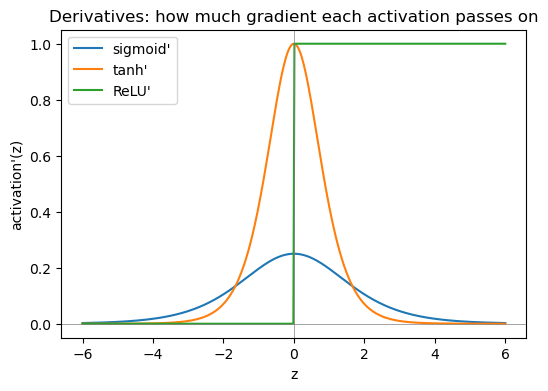

sigmoid'(0) = 0.25   sigmoid'(6) = 0.002466509291359931
tanh'(0)    = 1.0   tanh'(6)    = 2.4576547405286142e-05
ReLU'(-1)   = 0.0   ReLU'(1)    = 1.0


In [9]:
import matplotlib.pyplot as plt

def sigmoid_np(x): return 1.0 / (1.0 + np.exp(-x))
def sigmoid_prime(x): return sigmoid_np(x) * (1 - sigmoid_np(x))
def tanh_prime(x): return 1 - np.tanh(x) ** 2
def relu_prime(x): return (x > 0).astype(float)

x = np.linspace(-6, 6, 400)
plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid_prime(x), label="sigmoid'")
plt.plot(x, tanh_prime(x), label="tanh'")
plt.plot(x, relu_prime(x), label="ReLU'")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.legend()
plt.title("Derivatives: how much gradient each activation passes on")
plt.xlabel("z"); plt.ylabel("activation'(z)")
plt.savefig("../figs/day09-activation-derivatives.png" if os.path.isdir("../figs") else "day09-activation-derivatives.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("sigmoid'(0) =", sigmoid_prime(np.array([0.0]))[0], "  sigmoid'(6) =", sigmoid_prime(np.array([6.0]))[0])
print("tanh'(0)    =", tanh_prime(np.array([0.0]))[0], "  tanh'(6)    =", tanh_prime(np.array([6.0]))[0])
print("ReLU'(-1)   =", relu_prime(np.array([-1.0]))[0], "  ReLU'(1)    =", relu_prime(np.array([1.0]))[0])

| Activation | Range | Zero-centered? | Saturates? | Known problem |
|---|---|---|---|---|
| Sigmoid | $(0,1)$ | No | Both ends | Derivative at most 0.25, so gradients shrink at every layer |
| Tanh | $(-1,1)$ | Yes | Both ends | Still vanishes, though less severely (derivative up to 1.0) |
| ReLU | $[0,\infty)$ | No | Only for $z<0$ (derivative exactly 0) | "Dying ReLU": a unit stuck at $z<0$ for every input never recovers |

Sigmoid's derivative peaks at just 0.25 and is below 0.01 by $|z| = 6$.
Multiply a few of those together and almost nothing is left. ReLU's
derivative is exactly 1 for any positive input, so it never shrinks the
gradient there. Its weakness is the flat side: **Leaky ReLU**
($\max(0.01z, z)$) and **GELU** (a smooth ReLU-like curve used in
transformers) keep a small slope for $z < 0$ to avoid dead units. Now the
effect across six layers:

In [10]:
class DeepNet(nn.Module):
    def __init__(self, activation_cls, depth=6, width=64, input_dim=SEQ_LEN * len(AMINO_ACIDS)):
        super().__init__()
        layers, d = [], input_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), activation_cls()]
            d = width
        layers += [nn.Linear(width, 5)]
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

loss_fn = nn.CrossEntropyLoss()
for name, activation_cls in [("sigmoid", nn.Sigmoid), ("ReLU", nn.ReLU)]:
    torch.manual_seed(0)
    net = DeepNet(activation_cls)
    logits = net(X_train_t)
    loss = loss_fn(logits, y_train_t)
    weight_params = [p for p in net.parameters() if p.dim() == 2]
    grads = torch.autograd.grad(loss, weight_params)
    magnitudes = [g.abs().mean().item() for g in grads]
    print(f"{name:8s} mean |gradient| per layer, input-side first:")
    print("        ", [f"{m:.2e}" for m in magnitudes])
    print(f"        ratio (output layer / input layer): {magnitudes[-1] / magnitudes[0]:.0f}x")
    print()

sigmoid  mean |gradient| per layer, input-side first:
         ['8.26e-09', '3.18e-07', '2.08e-06', '1.67e-05', '1.25e-04', '9.57e-04', '2.67e-02']
        ratio (output layer / input layer): 3228702x

ReLU     mean |gradient| per layer, input-side first:
         ['4.21e-06', '3.78e-06', '3.58e-06', '7.26e-06', '1.96e-05', '4.09e-05', '5.93e-04']
        ratio (output layer / input layer): 141x



With sigmoid, the gradient reaching the layer closest to the input is
roughly **three million times smaller** than the gradient reaching the output
layer — that layer's weights would barely move under gradient descent,
even though it still needs to learn something useful. ReLU's gradients
shrink far less across the same depth, which is why it (or variants of
it) is the default choice for hidden layers in modern networks.

The three main tools against this, alongside choosing ReLU-like
activations: **weight initialization** schemes that start each layer's
weights at a scale matched to its size (avoiding saturation from the
very first forward pass), **input standardization** (centering/scaling
inputs so no single feature dominates), and **batch normalization**
(normalizing the *activations* between layers during training, so later
layers don't have to keep adapting to a shifting input distribution). This
network's input is already binary one-hot (already on a fixed, bounded
scale), so standardization matters less here than it would for a network
with raw continuous inputs — worth knowing, not always worth applying
blindly.

### Further reading

- Wikipedia, [Vanishing gradient problem](https://en.wikipedia.org/wiki/Vanishing_gradient_problem)
- Ioffe & Szegedy (2015), "Batch Normalization," [arXiv:1502.03167](https://arxiv.org/abs/1502.03167)

## Regularization: dropout, L2, and early stopping

Three practical tools against the overfitting seen above:

- **Dropout** randomly zeroes a fraction of a layer's activations during
  each training step, preventing the network from relying too heavily on
  any single unit.
- **L2 regularization** (a.k.a. weight decay) adds a penalty proportional
  to the *square* of the weights to the loss, discouraging any single
  weight from growing large; PyTorch applies it via the optimizer's
  `weight_decay` argument, not a separate loss term. **L1 regularization**
  (Lasso) uses the *absolute value* instead, and tends to push some
  weights to exactly zero rather than just shrinking all of them.
- **Early stopping** — simply not training past the epoch where
  validation performance peaks — costs nothing extra to implement and is
  often the single most effective fix.

In [11]:
torch.manual_seed(0)
model_reg = SubcellularLocalizationClassifier(dropout=0.5)
optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-3, weight_decay=1e-3)  # L2 via weight_decay
loss_fn = nn.CrossEntropyLoss()

best_val_acc, best_epoch, best_state = 0.0, 0, None
history_reg = []
for epoch in range(100):
    model_reg.train()
    optimizer.zero_grad()
    logits = model_reg(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()

    model_reg.eval()
    with torch.no_grad():
        train_acc = (model_reg(X_train_t).argmax(1).numpy() == y_train).mean()
        val_acc = (model_reg(X_val_t).argmax(1).numpy() == y_val).mean()
    history_reg.append((epoch, train_acc, val_acc))
    if val_acc > best_val_acc:
        best_val_acc, best_epoch = val_acc, epoch
        best_state = {k: v.clone() for k, v in model_reg.state_dict().items()}

print(f"best validation accuracy: {best_val_acc:.3f}, reached at epoch {best_epoch}")
print(f"training accuracy at end of the full 100-epoch run: {history_reg[-1][1]:.3f}")
model_reg.load_state_dict(best_state)  # roll back to the early-stopped weights

best validation accuracy: 0.476, reached at epoch 13
training accuracy at end of the full 100-epoch run: 1.000


<All keys matched successfully>

Training accuracy still reaches 100% by the end: with ~190,000 parameters
and 486 training examples, the model can memorize the training set
whatever we do. What helps is **early stopping**. The unregularized run
peaked at 0.486 validation accuracy (epoch 5) and had sunk to 0.438 by
epoch 29. Rolling back to the best epoch keeps the network near its peak.
Adding dropout and L2 did *not* improve on that peak here (0.476 at epoch
13, vs. 0.486 without them). Regularization is not a substitute for having
enough data relative to model size. This is a real limitation of this
small, deliberately simple case study, and part of why production tools
for this exact problem (e.g. DeepLoc) use much larger training sets and
more parameter-efficient input representations than a flattened one-hot
encoding.

### Further reading

- Wikipedia, [Regularization (mathematics)](https://en.wikipedia.org/wiki/Regularization_(mathematics)), [Dropout (neural networks)](https://en.wikipedia.org/wiki/Dropout_(neural_networks)), [Early stopping](https://en.wikipedia.org/wiki/Early_stopping)

## Evaluating the trained model

The epoch was chosen on the validation set, so validation accuracy is now
slightly optimistic (Day 8). The final, honest numbers come from the
**test set**, used here for the first and only time. They are
directly comparable to Day 8's untrained baseline.

In [12]:
model_reg.eval()
with torch.no_grad():
    val_acc_final = (model_reg(X_val_t).argmax(1).numpy() == y_val).mean()
    test_logits = model_reg(X_test_t)
predicted_classes = test_logits.argmax(dim=1).numpy()
predicted_probs = torch.softmax(test_logits, dim=1).numpy()

print(f"validation accuracy (used to pick the epoch): {val_acc_final:.3f}")
accuracy = (predicted_classes == y_test).mean()
print(f"TEST accuracy: {accuracy:.3f}  (chance: 0.20)")

cm = confusion_matrix(y_test, predicted_classes)
print("\nconfusion matrix on the test set (rows = true class, columns = predicted class):")
print("classes:", CLASS_NAMES)
print(cm)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, predicted_classes, average="macro", zero_division=0
)
print(f"\nmacro precision: {precision:.3f}   macro recall: {recall:.3f}   macro F1: {f1:.3f}")
print(f"MCC: {matthews_corrcoef(y_test, predicted_classes):.3f}")
print(f"macro AUROC: {roc_auc_score(y_test, predicted_probs, multi_class='ovr'):.3f}")

validation accuracy (used to pick the epoch): 0.476
TEST accuracy: 0.514  (chance: 0.20)

confusion matrix on the test set (rows = true class, columns = predicted class):
classes: ['Cytoplasm', 'Nucleus', 'Mitochondrion', 'Secreted', 'Cell membrane']
[[ 6 10  2  0  3]
 [ 5  8  2  3  3]
 [ 4  3  7  2  5]
 [ 1  2  3 18  1]
 [ 0  1  0  3 17]]

macro precision: 0.497   macro recall: 0.506   macro F1: 0.493
MCC: 0.394
macro AUROC: 0.831


### Does the hidden layer beat a linear model here?

A fair question after Day 6's lab, where plain linear regression held its
own against a small MLP. The same comparison on this split: Day 8's
logistic-regression baseline (a linear model, no hidden layer), trained on
the same training set and scored on the same test set:

In [13]:
from sklearn.linear_model import LogisticRegression
linear = LogisticRegression(max_iter=2000, random_state=0).fit(X_train, y_train)
lin_pred = linear.predict(X_test)
print(f"logistic regression -- TEST accuracy: {(lin_pred == y_test).mean():.3f}   "
      f"MCC: {matthews_corrcoef(y_test, lin_pred):.3f}   "
      f"macro AUROC: {roc_auc_score(y_test, linear.predict_proba(X_test), multi_class='ovr'):.3f}")
print(f"trained MLP         -- TEST accuracy: {accuracy:.3f}   "
      f"MCC: {matthews_corrcoef(y_test, predicted_classes):.3f}   "
      f"macro AUROC: {roc_auc_score(y_test, predicted_probs, multi_class='ovr'):.3f}")

logistic regression -- TEST accuracy: 0.569   MCC: 0.461   macro AUROC: 0.849
trained MLP         -- TEST accuracy: 0.514   MCC: 0.394   macro AUROC: 0.831


**The linear model wins.** On this small, homology-partitioned dataset
the hidden layer does not pay for its ~190,000 parameters, much like the
Day 6 lab. That is an honest and common outcome. A hidden layer helps
when there are interactions between inputs that a linear model cannot
represent (Day 6's XOR) *and* enough data to learn them. Here the data is
the bottleneck. Always compare against a simple baseline before believing
that a deeper model is better.

Every metric improves substantially over Day 8's untrained baseline
(accuracy 0.181, MCC −0.027, macro AUROC 0.474 on the validation set).

## The payoff: what this whole arc was building toward

Trace the pieces back: Day 5 introduced the profile/PSSM score as a
weighted sum over sequence positions — already a linear model. Day 6
formalized that as a perceptron, showed its weights can be *learned*
rather than derived, and demonstrated a real limitation (the XOR-shaped
Bulyk et al. example) that only a **hidden layer** resolves. Day 8 wrote
that hidden-layer model the proper PyTorch way. This notebook just
trained it — with real backpropagation, real regularization — on a real
multi-class biological problem.

Rost & Sander's **PHD** method (already introduced on Day 6) is the same
recipe at the scale that mattered historically: profile input (Day 5) +
a hidden layer (Day 6) + a trained feed-forward network (this notebook's
training loop) + a 3-class softmax output (helix / sheet / coil — Day
8's softmax section) trained on real protein structures. That combination
is what pushed single-sequence secondary-structure prediction past the
60-65% plateau to over 70% accuracy in the early 1990s — the same
Rost & Sander (1993) result already cited on Day 6, now with every piece
of the machinery behind it fully explained rather than taken on faith.

## Try it yourself

Try `weight_decay=0` (no L2) with dropout still on, or vice versa, and
compare the best validation accuracy and the epoch it's reached at.
Try `hidden_dim=16` instead of 64 in `SubcellularLocalizationClassifier`
— a smaller model has less capacity to overfit in the first place; does
it need as much help from regularization to reach a similar validation
accuracy?